In [1]:
from geostat_isoscapes_tools import geostat_utils as gutils, plot_utils as putils, sisal_utils as sutils, utils
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 
import json
import os 
import numpy as np
import plotly.io as pio
pio.renderers.default = "vscode"

from geostat_isoscapes_tools import variogram_models
import matplotlib.cm as cm
from matplotlib.colors import Normalize, ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable


sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})
plt.close("all") 

In this notebook, we compare variograms of itrace and sisal data. In particular, we select itrace data with the union of circles centered around sisal points at each time slice.
Hence, we developped a function that automatically defines the mask, iterate over itrace time slices to compute their variograms, then aggregate them and save the results. 

This workflow is can be run using the script ```variogram_parameters_scan```, where all parameters can be set and looped on.
The results will automatically be saved in output folders (see logs when running).

This notebook can still be useful to visualize the trend fitting results, variograms parameters and semivariances...

### Variography results  

In [2]:
def open_trend_metrics_and_df(results_dict,t):
    df, metrics = gutils.multiple_linear_result_dict_to_df(results_dict[t])
    metrics['time']= t_num
    df['time']= t_num
    df['r2']=results_dict[t]['r2']
    df['r2adj']=results_dict[t]['adj_r2']
    df['mae']=results_dict[t]['mae']
    return df,metrics

In [83]:
# PARAMETERS 
folder_exp = f'../output/variograms/2026-05-18_cosh/'
itrace = True
sisal = True
str_vario_params_itrace = 'maxlag10000000nlags20'
str_vario_params_sisal = 'maxlag10000000nlags20'
res = 200
trend='trend_multiple_linear_lat_latquad_ele_D'
azimuths = [None]

In [84]:
# LOAD TREND RESULTS AND VARIOGRAMS 
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)

list_varioparams_itrace,list_trend_df_itrace,list_trend_metrics_itrace,list_trend_df_sisal,list_trend_metrics_sisal,list_varioparams_sisal,list_semivar_sisal,list_semivar_itrace=[],[],[],[],[],[],[],[]

for yrBP in itrace_sims.keys():
    if yrBP != '_comment':
        for azimuth in azimuths:
            if itrace:
                fp_itrace = f'{folder_exp}itrace/sim{yrBP}kyrBP/res{res}/{str_vario_params_itrace}/{trend}/sisal_mask_2000km/' ### PUT PATH HERE 
                with open(fp_itrace+f'trend_metrics{azimuth}.json', 'r') as f: # 'None' refers to the (un)directionality of the variogram ('azimuth' in parameters scan)
                    results_dict_itrace = json.load(f)
                itrace_gammas = pd.read_csv(fp_itrace + f'vario_{azimuth}_df_all_iterations.csv')
                itrace_gammas['azimuth'] = azimuth
                list_semivar_itrace.append(itrace_gammas)
            if sisal:
                fp_sisal = f'{folder_exp}sisal/slice{yrBP}kyrBP/res{res}/{str_vario_params_sisal}/{trend}/' ### PUT PATH HERE 
                with open(fp_sisal+f'trend_metrics{azimuth}.json', 'r') as f:
                    results_dict_sisal = json.load(f)
            timesteps = list(results_dict_itrace.keys()) if itrace else list(results_dict_sisal.keys())

            for i,t in enumerate(timesteps):
                t_num = int(float(t))
                if itrace :
                    df, metrics = open_trend_metrics_and_df(results_dict_itrace,t)
                    df['azimuth'] = azimuth
                    metrics['azimuth'] = azimuth
                    list_trend_df_itrace.append(df)
                    list_trend_metrics_itrace.append(metrics)

                    with open(f'{fp_itrace}variogram_params_{azimuth}_t{t_num}.json', 'r') as f:
                        vario_params_itrace = json.load(f)
                    vario_params_itrace['time'] = t_num
                    vario_params_itrace['azimuth'] = azimuth
                    list_varioparams_itrace.append(pd.DataFrame([vario_params_itrace]))
                
                if sisal :
                    df, metrics = open_trend_metrics_and_df(results_dict_sisal,str(int(float(t))))
                    df['azimuth'] = azimuth
                    metrics['azimuth'] = azimuth
                    list_trend_df_sisal.append(df)
                    list_trend_metrics_sisal.append(metrics)
                    sisal_gammas = pd.read_csv(f'{fp_sisal}vario_{azimuth}_df_all_iterations.csv')
                    sisal_gammas['azimuth'] = azimuth
                    list_semivar_sisal.append(sisal_gammas)

                    with open(f'{fp_sisal}variogram_params_{azimuth}_t{t_num}.json', 'r') as f:
                        vario_params_sisal = json.load(f)
                    vario_params_sisal['time'] = t_num
                    vario_params_sisal['azimuth'] = azimuth
                    list_varioparams_sisal.append(pd.DataFrame([vario_params_sisal]))

if itrace :           
    result_trend_df_itrace = pd.concat(list_trend_df_itrace).reset_index(drop=True)
    metrics_df_itrace = pd.concat(list_trend_metrics_itrace).reset_index(drop=True)
    varioparams_itrace_df = pd.concat(list_varioparams_itrace).reset_index(drop=True)
    gammas_itrace_df = pd.concat(list_semivar_itrace).reset_index(drop=True)
if sisal:
    result_trend_df_sisal = pd.concat(list_trend_df_sisal).reset_index(drop=True)
    metrics_df_sisal = pd.concat(list_trend_metrics_sisal).reset_index(drop=True)
    varioparams_sisal_df = pd.concat(list_varioparams_sisal).reset_index(drop=True)
    gammas_sisal_df = pd.concat(list_semivar_sisal).reset_index(drop=True)

#### Investigation of trend models coefficients and metrics

In [85]:
# which trend results are we interested in ?
result_df = result_trend_df_itrace
metrics_df = metrics_df_itrace

In [86]:
print('Mean MAE :',np.mean(result_df['mae']))
print('Mean r2 :',np.mean(result_df['r2']))
print('Mean r2adj :',np.mean(result_df['r2adj']))
print('std MAE :',np.std(result_df['mae']))
print('std r2 :',np.std(result_df['r2']))
print('std r2adj :',np.std(result_df['r2adj']))

Mean MAE : 2.795128131371628
Mean r2 : 0.9170360050863073
Mean r2adj : 0.9169816512599475
std MAE : 0.17605950475024734
std r2 : 0.00658261729042437
std r2adj : 0.006585260951033151


In [87]:
metrics_df.loc[metrics_df['name']=='latblock','vif'].mean()

np.float64(1.0997708851053318)

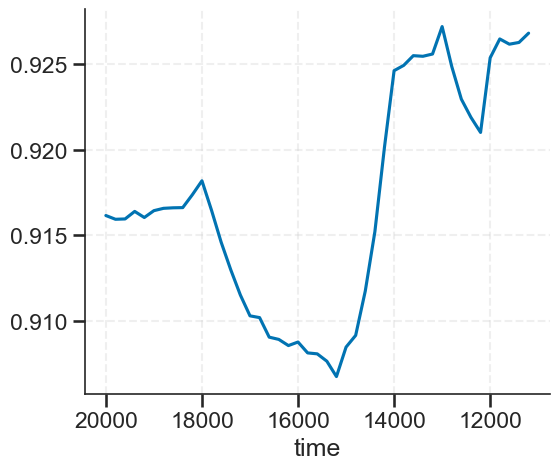

In [88]:
fig,ax = plt.subplots(figsize=(6,5))
result_df.groupby('time')['r2adj'].mean().plot(ax=ax)
sns.despine()
plt.grid(linestyle='--',alpha=0.3)
ax.invert_xaxis()
plt.show()
# plt.scatter(result_df['time'],result_df['r2adj'])

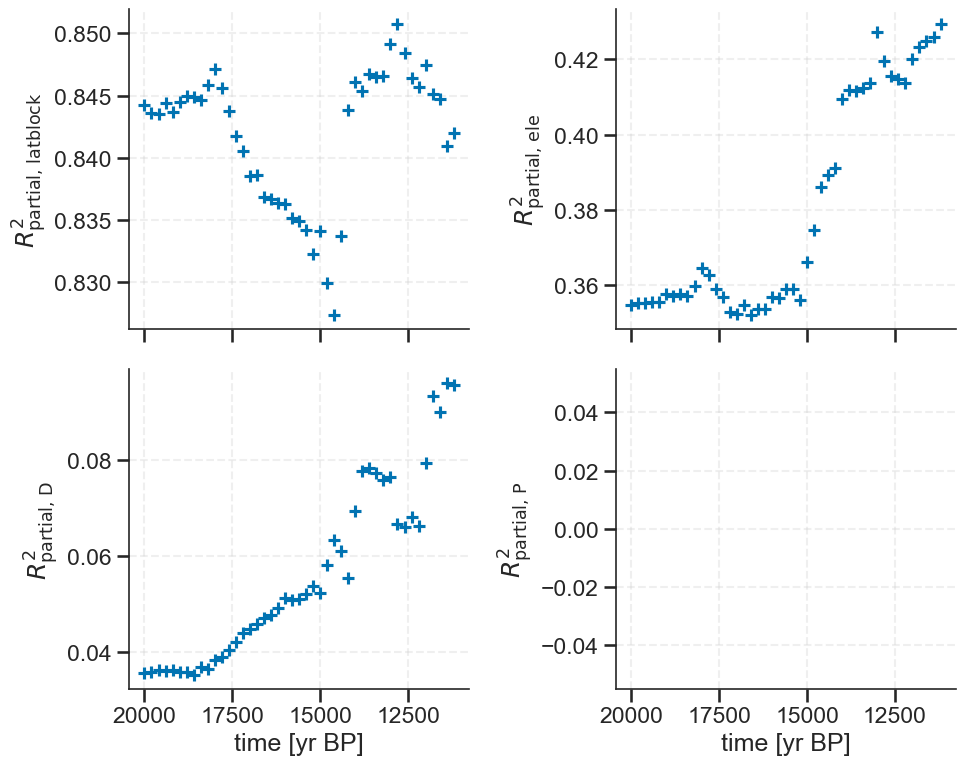

In [89]:
fig,axes = plt.subplots(2,2,sharex=True,figsize=(10,8))
for i,pred in enumerate(['latblock','ele','D','P']):
    ax = axes[i//2,i%2]
    ax.scatter(metrics_df.loc[metrics_df.name==pred,'time'].values,metrics_df.loc[metrics_df.name==pred,'partial r2'].values,marker='+',label=pred)
    ax.set_ylabel(rf'$R^2_\text{{partial, {pred}}}$')
    ax.grid(linestyle='--',alpha=0.3)

axes[1,1].set_xlabel('time [yr BP]')
axes[1,0].set_xlabel('time [yr BP]')
sns.despine()
axes[0,0].invert_xaxis()

plt.tight_layout()
# plt.savefig('../output/trendmodel_partial_r2_allpredictors.png',dpi=500)
plt.show()


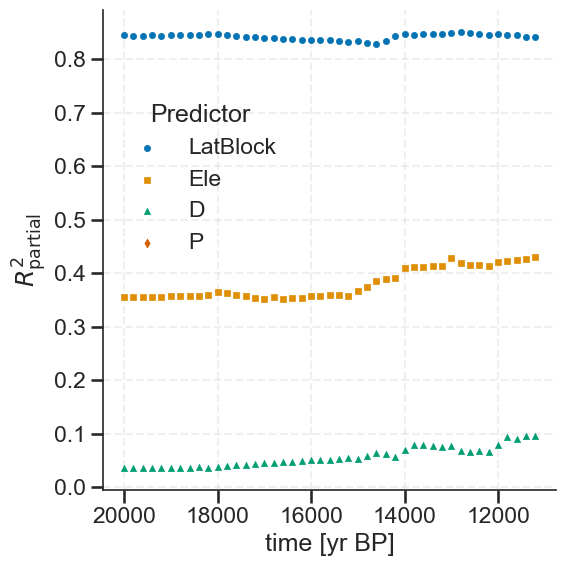

In [90]:
latblock = 'latblock'

fig, ax = plt.subplots(figsize=(6,6))
preds = [latblock,'ele','D','P']
preds_name = ['LatBlock','Ele','D','P']
colors = sns.color_palette("colorblind", n_colors=len(preds))
markers = ['o','s','^','d']

for p, c, m in zip(preds, colors, markers):
    sub = metrics_df.loc[metrics_df.name == p]
    ax.scatter(sub['time'].values, sub['partial r2'].values, label=preds_name[preds.index(p)], color=c, marker=m, s=20,linewidths=0.5)

ax.set_ylabel(r'$R^2_{\mathrm{partial}}$')
ax.set_xlabel('time [yr BP]')
ax.grid(which='both',linestyle='--', alpha=0.3)
ax.locator_params(axis='y', nbins=10)
ax.invert_xaxis()
ax.legend(title='Predictor', loc='center left', bbox_to_anchor=(0, 0.65), frameon=False)
sns.despine()
plt.tight_layout()
# plt.savefig('../output/essd_figs/fig3.png', dpi=300)
plt.show()

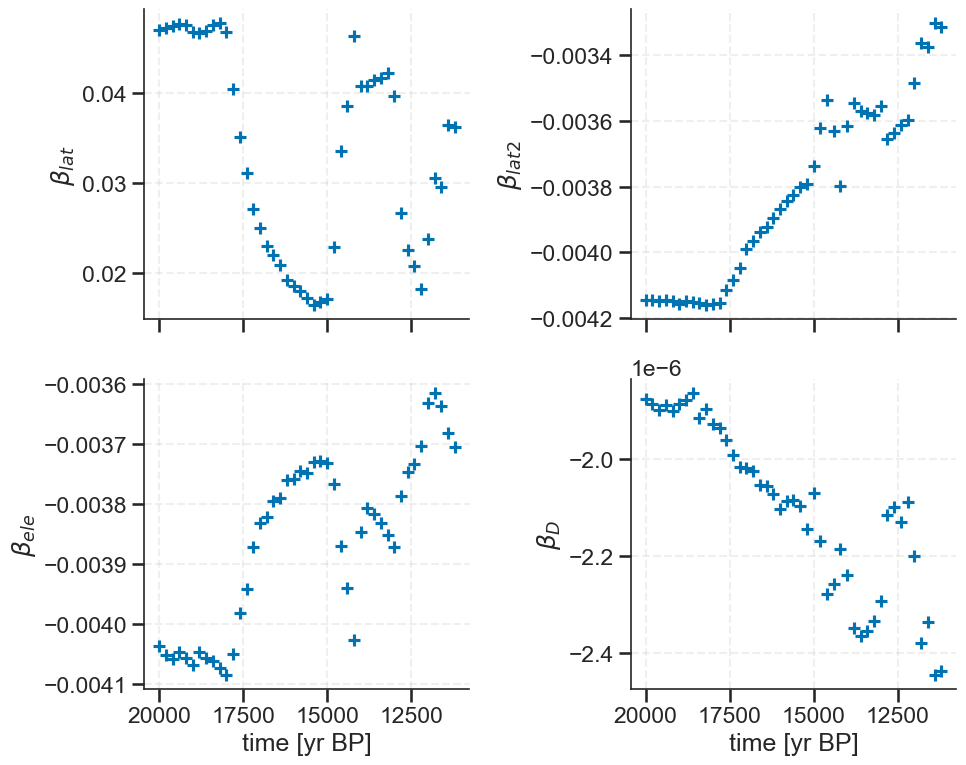

In [91]:
fig,axes = plt.subplots(2,2,sharex=True,figsize=(10,8))
for i,pred in enumerate(['lat','lat2','ele','D']):
    ax = axes[i//2,i%2]
    ax.scatter(result_df.loc[result_df.name==pred,'time'].values,result_df.loc[result_df.name==pred,'beta'].values,marker='+',label=pred)
    ax.set_ylabel(rf'$\beta_{{{pred}}}$')
    ax.grid(linestyle='--',alpha=0.3)

axes[1,1].set_xlabel('time [yr BP]')
axes[1,0].set_xlabel('time [yr BP]')
sns.despine()
axes[0,0].invert_xaxis()

plt.tight_layout()
# plt.savefig('../output/trendmodel_partial_r2_allpredictors.png',dpi=500)
plt.show()


#### Investigation of variogram parameters

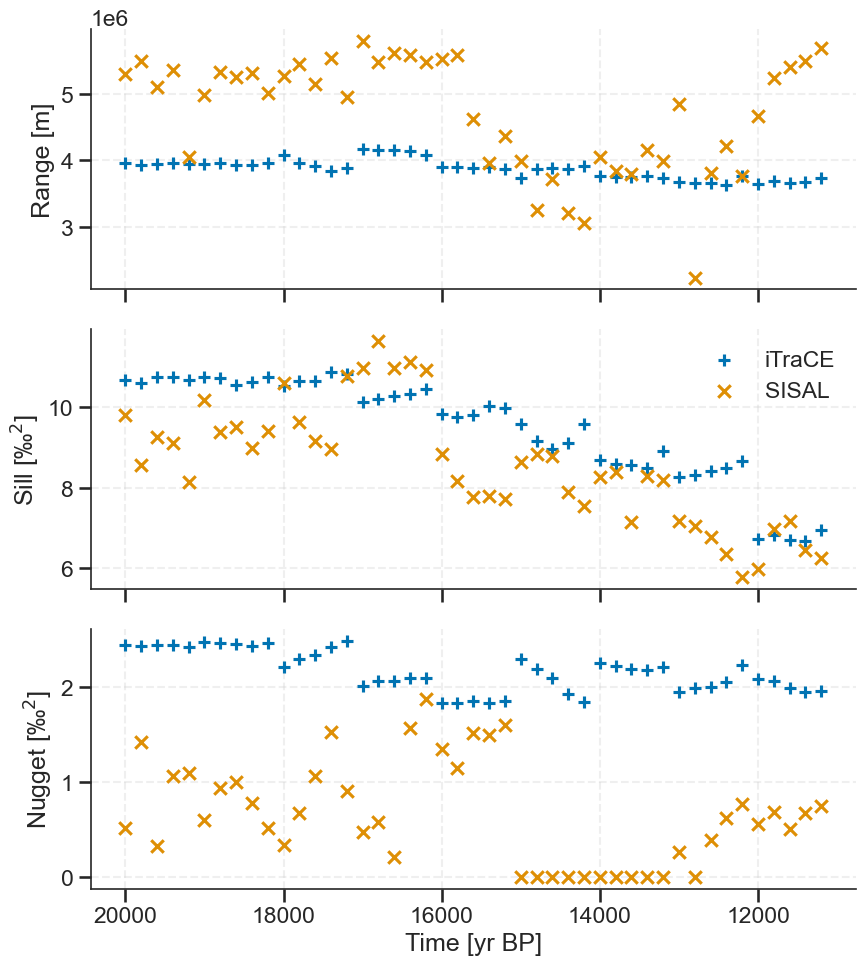

In [92]:
fig, axes = plt.subplots(3,1,figsize=(9,10),sharex='col',)#gridspec_kw={'width_ratios': [0.65, 0.35]})

# Left column: Scatter plots over time
axes[0].scatter(varioparams_itrace_df['time'].values,varioparams_itrace_df['range_spherical'].values,marker='+',label='iTraCE')
axes[0].scatter(varioparams_sisal_df['time'].values,varioparams_sisal_df['range_spherical'].values,marker='x',label='SISAL')
axes[0].set_ylabel('Range [m]')
axes[1].scatter(varioparams_itrace_df['time'].values,varioparams_itrace_df['sill_spherical'].values,marker='+',label='iTraCE')
axes[1].scatter(varioparams_sisal_df['time'].values,varioparams_sisal_df['sill_spherical'].values,marker='x',label='SISAL')
axes[1].set_ylabel(r'Sill [‰$^2$]')
axes[2].scatter(varioparams_itrace_df['time'].values,varioparams_itrace_df['nugget'].values,marker='+',label='iTraCE')
axes[2].scatter(varioparams_sisal_df['time'].values,varioparams_sisal_df['nugget'].values,marker='x',label='SISAL')
axes[2].set_ylabel(r'Nugget [‰$^2$]')
axes[2].set_xlabel('Time [yr BP]')
axes[1].legend(frameon=False)

# Right column: Boxplots comparing distributions
# params_list = ['range_spherical', 'sill_spherical', 'nugget']
# labels_list = ['Range', 'Sill', 'Nugget']
# ylabels_lists = [['Range [m]'], [r'Sill [‰$^2$]'], [r'Nugget [‰$^2$]']]
# colors = sns.color_palette("colorblind", 2)
# for i, (param, label) in enumerate(zip(params_list, labels_list)):
#     data_to_plot = [varioparams_itrace_df[param].dropna(), vario_sisal_df[param].dropna()]
#     bp = axes[i,1].boxplot(data_to_plot, tick_labels=['iTraCE', 'SISAL'], patch_artist=True)
    
#     # Color the boxes to match the scatter plot colors
#     for patch, color in zip(bp['boxes'], colors):
#         patch.set_facecolor(color)
    
#     # Color the median lines black
#     for median in bp['medians']:
#         median.set_color('black')
#         median.set_linewidth(2)
    
#     axes[i,1].set_ylabel(ylabels_lists[i][0])
#     axes[i,1].grid(axis='y', linestyle='--', alpha=0.3)
#     axes[i,1].set_title(f'{label} Distribution')

# axes[2,1].set_xlabel('Dataset')

# Apply styling to all subplots
sns.despine(top=True,right=True)
axes[0].invert_xaxis()
axes[0].grid()
axes[1].grid()
axes[2].grid()

plt.tight_layout()
# plt.savefig('../output/essd_figs/fig_variogram_params_over_time.png',dpi=300)
plt.show()

#### Anisotropy

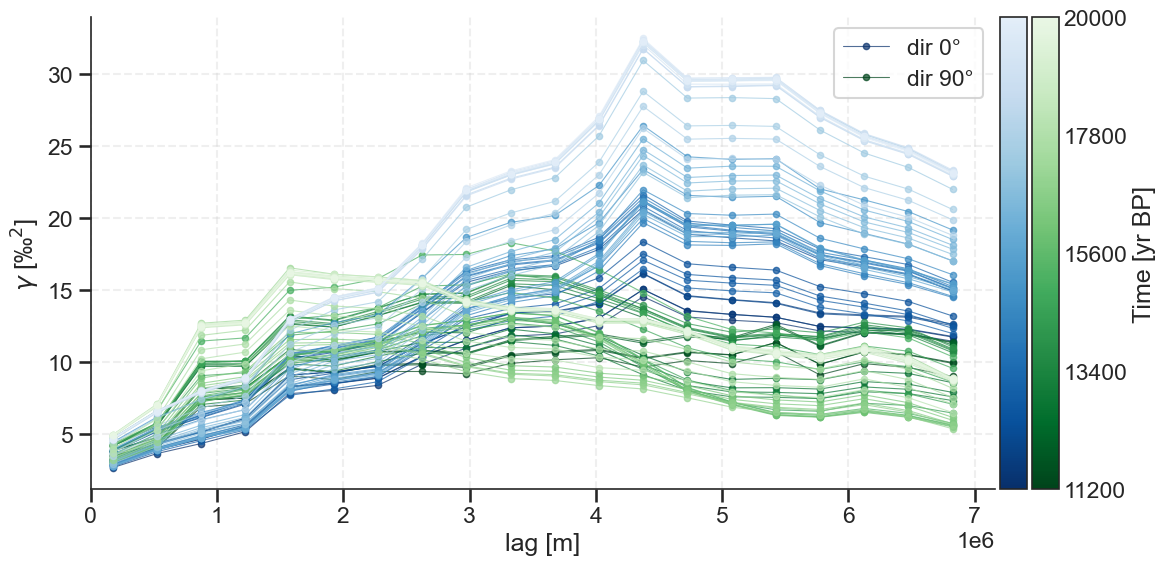

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

time_min, time_max = min(gammas_itrace_df.time_slice.values), max(gammas_itrace_df.time_slice.values)
norm = Normalize(vmin=time_min, vmax=time_max)

full_cmap_blue = cm.get_cmap('Blues_r')
full_cmap_green = cm.get_cmap('Greens_r')
cmap_blue = ListedColormap(full_cmap_blue(np.linspace(0., 0.9, 256)))
cmap_green = ListedColormap(full_cmap_green(np.linspace(0., 0.9, 256)))

for t,vario_t in gammas_itrace_df.groupby('time_slice') :
    vario_t_0 = vario_t[vario_t['azimuth']==0]
    vario_t_90 = vario_t[vario_t['azimuth']==90]

    bin_centers_0 = vario_t_0['lag'] - np.r_[vario_t_0['lag'].values[0],np.diff(vario_t_0['lag'])]/2
    bin_centers_90 = vario_t_90['lag'] - np.r_[vario_t_90['lag'].values[0],np.diff(vario_t_90['lag'])]/2
    color_0 = cmap_blue(norm(t))
    color_90 = cmap_green(norm(t))
    ax.plot(bin_centers_0, vario_t_0['gamma'], '.-', linewidth=0.8, alpha=0.7, color=color_0, label='dir 0°' if t==time_min else None)
    ax.plot(bin_centers_90, vario_t_90['gamma'], '.-', linewidth=0.8, alpha=0.7, color=color_90, label='dir 90°' if t==time_min else None)

ax.set_xlabel('lag [m]')
ax.set_xlim(0)
ax.set_ylabel(r'$\gamma$ [‰$^2$]')
# ax.set_title('SISAL and iTrace empirical residual variograms over 20-11 ka')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
ax.legend()


sm_blue = cm.ScalarMappable(norm=norm, cmap=cmap_blue)
sm_blue.set_array([])
sm_green = cm.ScalarMappable(norm=norm, cmap=cmap_green)
sm_green.set_array([])

divider = make_axes_locatable(ax)
cax_blue = divider.append_axes('right', size='3%', pad=0.05)
cax_green = divider.append_axes('right', size='3%', pad=0.05)

cbar_blue = plt.colorbar(sm_blue, cax=cax_blue)
cbar_green = plt.colorbar(sm_green, cax=cax_green)
cbar_blue.set_ticks([])
cbar_blue.set_ticklabels([])
cbar_blue.ax.yaxis.set_tick_params(size=0)
cbar_blue.set_label('')
ticks = np.linspace(time_min, time_max, 5)
cbar_green.set_ticks(ticks)
cbar_green.set_ticklabels([f"{int(t)}" for t in ticks])
cbar_green.ax.yaxis.set_tick_params(size=0)
cbar_green.set_label('Time [yr BP]')

plt.tight_layout()
# plt.savefig('../output/essd_figs/fig4_line_shading.png',dpi=300)
plt.show()

#### Variogram plot for ESSD 

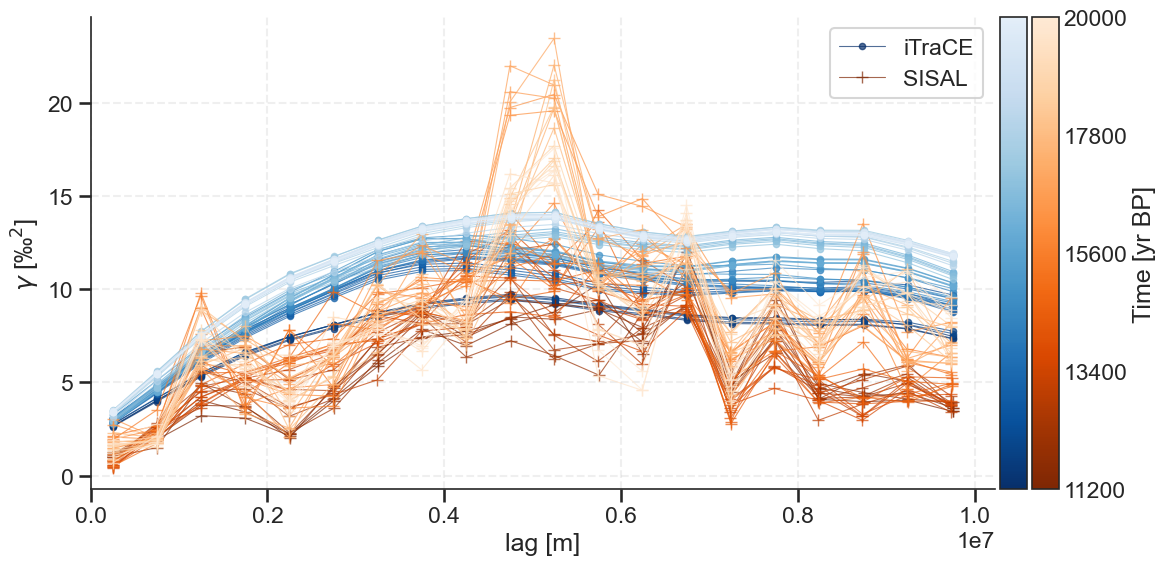

In [93]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create normalizer for time values (most recent should be darker)
all_times = []
for yrBP in itrace_sims.keys():
    if yrBP != '_comment':
        fp = f'{folder_exp}itrace/sim{yrBP}kyrBP/res{res}/{str_vario_params_itrace}/{trend}/sisal_mask_2000km/'
        itrace_vario = pd.read_csv(fp + 'vario_None_df_all_iterations.csv')
        all_times.extend(itrace_vario['time_slice'].unique())

time_min, time_max = min(all_times), max(all_times)
norm = Normalize(vmin=time_min, vmax=time_max)

full_cmap_blue = cm.get_cmap('Blues_r')
full_cmap_orange = cm.get_cmap('Oranges_r')
cmap_blue = ListedColormap(full_cmap_blue(np.linspace(0., 0.9, 256)))
cmap_orange = ListedColormap(full_cmap_orange(np.linspace(0., 0.9, 256)))

for yrBP in itrace_sims.keys():
    if yrBP != '_comment':
        fp = f'{folder_exp}itrace/sim{yrBP}kyrBP/res{res}/{str_vario_params_itrace}/{trend}/sisal_mask_2000km/'
        fp_sisal = f'{folder_exp}sisal/slice{yrBP}kyrBP/res{res}/{str_vario_params_sisal}/{trend}/'
        
        # Load and plot iTrace gammas in blue gradient
        itrace_vario = pd.read_csv(fp + 'vario_None_df_all_iterations.csv')
        for t,vario_t in itrace_vario.groupby('time_slice') :
            bin_centers = vario_t['lag'] - np.r_[vario_t['lag'].values[0],np.diff(vario_t['lag'])]/2
            color = cmap_blue(norm(t))
            ax.plot(bin_centers, vario_t['gamma'], '.-', linewidth=0.8, alpha=0.7, color=color, label='iTraCE' if t==time_min else None)
        
        # Load and plot SISAL gammas in red gradient
        sisal_vario = pd.read_csv(fp_sisal + 'vario_None_df_all_iterations.csv')
        for t,vario_t in sisal_vario.groupby('time_slice') :
            bin_centers = vario_t['lag'] - np.r_[vario_t['lag'].values[0],np.diff(vario_t['lag'])]/2
            color = cmap_orange(norm(t))
            ax.plot(bin_centers, vario_t['gamma'], '+-', linewidth=0.8, alpha=0.7, color=color, label='SISAL' if t==time_min else None)

ax.set_xlabel('lag [m]')
ax.set_xlim(0)
ax.set_ylabel(r'$\gamma$ [‰$^2$]')
# ax.set_title('SISAL and iTrace empirical residual variograms over 20-11 ka')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
ax.legend()


sm_blue = cm.ScalarMappable(norm=norm, cmap=cmap_blue)
sm_blue.set_array([])
sm_orange = cm.ScalarMappable(norm=norm, cmap=cmap_orange)
sm_orange.set_array([])

divider = make_axes_locatable(ax)
cax_blue = divider.append_axes('right', size='3%', pad=0.05)
cax_orange = divider.append_axes('right', size='3%', pad=0.05)

cbar_blue = plt.colorbar(sm_blue, cax=cax_blue)
cbar_orange = plt.colorbar(sm_orange, cax=cax_orange)
cbar_blue.set_ticks([])
cbar_blue.set_ticklabels([])
cbar_blue.ax.yaxis.set_tick_params(size=0)
cbar_blue.set_label('')
ticks = np.linspace(time_min, time_max, 5)
cbar_orange.set_ticks(ticks)
cbar_orange.set_ticklabels([f"{int(t)}" for t in ticks])
cbar_orange.ax.yaxis.set_tick_params(size=0)
cbar_orange.set_label('Time [yr BP]')

plt.tight_layout()
# plt.savefig('../output/essd_figs/fig4_line_shading.png',dpi=300)
plt.show()

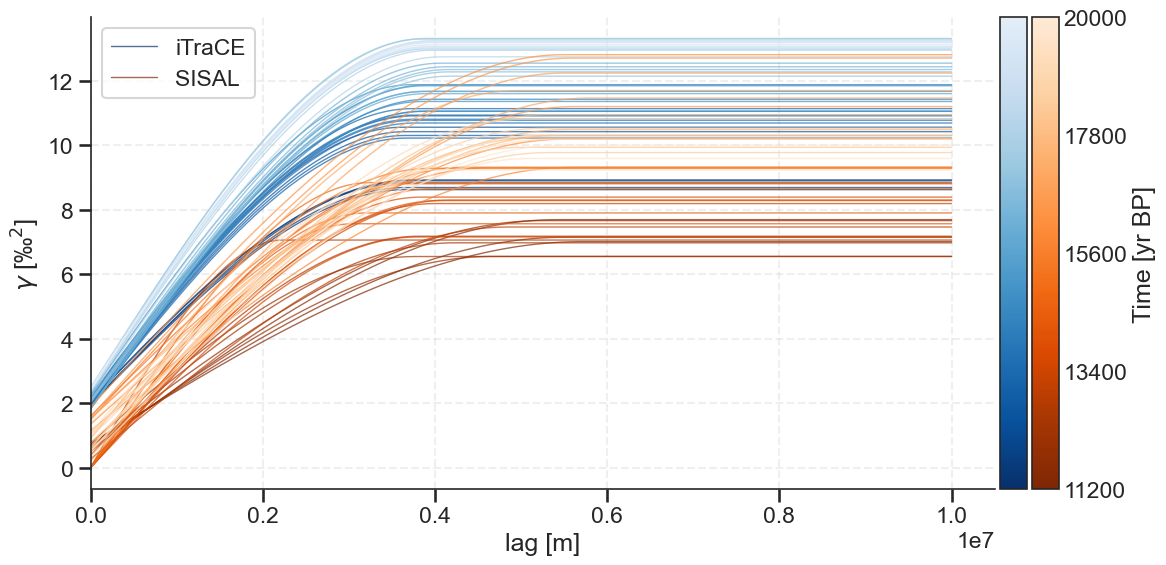

In [ ]:
from geostat_isoscapes_tools import variogram_models
import matplotlib.cm as cm
from matplotlib.colors import Normalize, ListedColormap

model = variogram_models.CompositeModel('spherical+nugget')
lags = np.linspace(start=0,stop=1e7,num=200)

fig, ax = plt.subplots(figsize=(12, 6))

# Create normalizer for time values (most recent should be darker)
time_min = min(varioparams_itrace_df['time'].min(), varioparams_sisal_df['time'].min())
time_max = max(varioparams_itrace_df['time'].max(), varioparams_sisal_df['time'].max())
norm = Normalize(vmin=time_min, vmax=time_max)

# Create truncated colormaps to avoid white shades (use 0.3 to 1.0 range)
full_cmap_blue = cm.get_cmap('Blues_r')
full_cmap_orange = cm.get_cmap('Oranges_r')
cmap_blue = ListedColormap(full_cmap_blue(np.linspace(0., 0.9, 256)))
cmap_orange = ListedColormap(full_cmap_orange(np.linspace(0., 0.9, 256)))

for t,vario_t in varioparams_itrace_df.groupby('time'):
    color = cmap_blue(norm(t))
    ax.plot(lags,model.get_model_func()(lags,vario_t['range_spherical'].values[0],vario_t['sill_spherical'].values[0],vario_t['nugget'].values[0]), '-', linewidth=1, alpha=0.7, color=color, label='iTraCE' if t==time_min else None)

for t,vario_t in varioparams_sisal_df.groupby('time') :
    color = cmap_orange(norm(t))
    ax.plot(lags,model.get_model_func()(lags,vario_t['range_spherical'].values[0],vario_t['sill_spherical'].values[0],vario_t['nugget'].values[0]), '-', linewidth=1, alpha=0.7, color=color, label='SISAL' if t==time_min else None)

ax.set_xlabel('lag [m]')
ax.set_xlim(0)
ax.set_ylabel(r'$\gamma$ [‰$^2$]')
# ax.set_title('SISAL and iTrace empirical residual variograms over 20-11 ka')

ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
ax.legend()

# colorbars
sm_blue = cm.ScalarMappable(norm=norm, cmap=cmap_blue)
sm_blue.set_array([])
sm_orange = cm.ScalarMappable(norm=norm, cmap=cmap_orange)
sm_orange.set_array([])
divider = make_axes_locatable(ax)
cax_blue = divider.append_axes('right', size='3%', pad=0.05)
cax_orange = divider.append_axes('right', size='3%', pad=0.05)
cbar_blue = plt.colorbar(sm_blue, cax=cax_blue)
cbar_orange = plt.colorbar(sm_orange, cax=cax_orange)
cbar_blue.set_ticks([])
cbar_blue.set_ticklabels([])
cbar_blue.ax.yaxis.set_tick_params(size=0)
cbar_blue.set_label('')
ticks = np.linspace(time_min, time_max, 5)
cbar_orange.set_ticks(ticks)
cbar_orange.set_ticklabels([f"{int(t)}" for t in ticks])
cbar_orange.ax.yaxis.set_tick_params(size=0)
cbar_orange.set_label('Time [yr BP]')


plt.tight_layout()
# plt.savefig('../output/essd_figs/fig4_models_shading.png',dpi=300)
plt.show()


What is the mean scaling factor between SISAL and iTraCe sills ?


In [105]:
# compute the mean scaling factor between sills of itrace and sisal 

sills_ratio =[]
for t,vario_t in varioparams_itrace_df.groupby('time'):
    vario_t_sisal = varioparams_sisal_df[varioparams_sisal_df['time']==t]
    if len(vario_t_sisal)!=0:
        sills_ratio.append(vario_t_sisal['sill_spherical'].values[0]/vario_t['sill_spherical'].values[0])

scaling_factor = np.median(sills_ratio)
print("Median scaling factor is",scaling_factor)
scaling_factor_std = np.std(sills_ratio)
print("Standard deviation of scaling factor is",scaling_factor_std)

Median scaling factor is 0.8979744867533548
Standard deviation of scaling factor is 0.10212529766123987


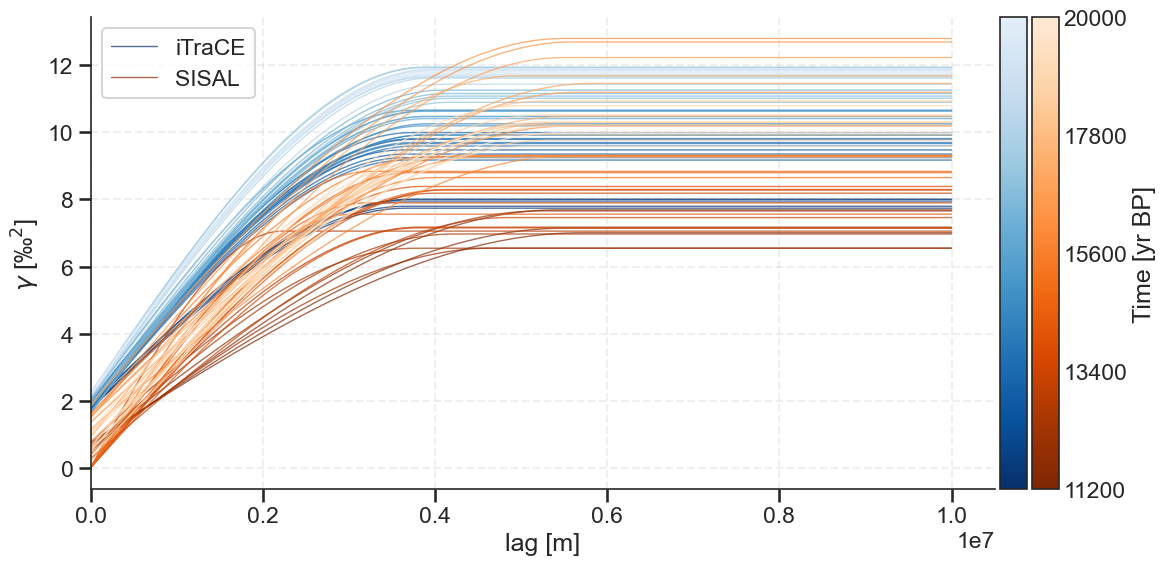

In [106]:
# plot the variogram models with scaled sills for better visual comparison of range and nugget parameters between iTrace and SISAL

fig, ax = plt.subplots(figsize=(12, 6))

for t,vario_t in varioparams_itrace_df.groupby('time'):
    color = cmap_blue(norm(t))
    ax.plot(lags,scaling_factor*(model.get_model_func()(lags,vario_t['range_spherical'].values[0],vario_t['sill_spherical'].values[0],vario_t['nugget'].values[0])), '-', linewidth=1, alpha=0.7, color=color, label='iTraCE' if t==time_min else None)

for t,vario_t in varioparams_sisal_df.groupby('time') :
    color = cmap_orange(norm(t))
    ax.plot(lags,model.get_model_func()(lags,vario_t['range_spherical'].values[0],vario_t['sill_spherical'].values[0],vario_t['nugget'].values[0]), '-', linewidth=1, alpha=0.7, color=color, label='SISAL' if t==time_min else None)

ax.set_xlabel('lag [m]')
ax.set_xlim(0)
ax.set_ylabel(r'$\gamma$ [‰$^2$]')
# ax.set_title('SISAL and iTrace empirical residual variograms over 20-11 ka')

ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
ax.legend()

# colorbars
sm_blue = cm.ScalarMappable(norm=norm, cmap=cmap_blue)
sm_blue.set_array([])
sm_orange = cm.ScalarMappable(norm=norm, cmap=cmap_orange)
sm_orange.set_array([])
divider = make_axes_locatable(ax)
cax_blue = divider.append_axes('right', size='3%', pad=0.05)
cax_orange = divider.append_axes('right', size='3%', pad=0.05)
cbar_blue = plt.colorbar(sm_blue, cax=cax_blue)
cbar_orange = plt.colorbar(sm_orange, cax=cax_orange)
cbar_blue.set_ticks([])
cbar_blue.set_ticklabels([])
cbar_blue.ax.yaxis.set_tick_params(size=0)
cbar_blue.set_label('')
ticks = np.linspace(time_min, time_max, 5)
cbar_orange.set_ticks(ticks)
cbar_orange.set_ticklabels([f"{int(t)}" for t in ticks])
cbar_orange.ax.yaxis.set_tick_params(size=0)
cbar_orange.set_label('Time [yr BP]')


plt.tight_layout()
# plt.savefig('../output/essd_figs/fig4_models_shading.png',dpi=300)
plt.show()


### Climatological variograms

In [2]:
from geostat_isoscapes_tools import geostat_utils as gutils
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 
import numpy as np
import plotly.io as pio
pio.renderers.default = "vscode"

sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})
plt.close("all") 

In [4]:
itrace_df = pd.read_csv('/media/luluxette/T7_Shield/pdm/itrace_res200yr_d18Ow_20_11_kaBP.csv')

In [5]:
itrace_df.columns

Index(['Unnamed: 0', 'd18Op', 'lat', 'lon', 'time', 'D', 'ele', 'resid',
       'resid_standardized'],
      dtype='object')

In [6]:
# REMOVE TRENDS 
trend = 'multiple_linear_lat_latquad_ele_D'
# to_add = ['ele','D']
# cols_exog = np.unique(np.array(to_add)).tolist()
# cols_exog.extend(['lat','lon'])
# exog_df = gutils.add_external_variables_to_lonlat_df(itrace_df,variables=to_add,verbose=False)[cols_exog] # type:ignore
# itrace_df = itrace_df.merge(exog_df,on=['lat','lon']) # type:ignore
# itrace_df = itrace_df.dropna(axis=0) # clean nans that come from exog variables
for t, df_t in itrace_df.groupby('time'):
    print(f'removing trend for time {t}...')
    itrace_df.loc[df_t.index, 'resid'],_ = gutils.trend_removal(trend,df_t,'d18Op',verbose=False)


removing trend for time 11200.0...
removing trend for time 11400.0...
removing trend for time 11600.0...
removing trend for time 11800.0...
removing trend for time 12000.0...
removing trend for time 12200.0...
removing trend for time 12400.0...
removing trend for time 12600.0...
removing trend for time 12800.0...
removing trend for time 13000.0...
removing trend for time 13200.0...
removing trend for time 13400.0...
removing trend for time 13600.0...
removing trend for time 13800.0...
removing trend for time 14000.0...
removing trend for time 14200.0...
removing trend for time 14400.0...
removing trend for time 14600.0...
removing trend for time 14800.0...
removing trend for time 15000.0...
removing trend for time 15200.0...
removing trend for time 15400.0...
removing trend for time 15600.0...
removing trend for time 15800.0...
removing trend for time 16000.0...
removing trend for time 16200.0...
removing trend for time 16400.0...
removing trend for time 16600.0...
removing trend for t

In [7]:
# CLIMATOLOGICAL VARIOGRAM from Bastin et al. 1984 :
# 1. Compute the variance of the field for each time step
S2k = itrace_df.groupby('time',observed=True)['resid'].std() # spatial standard deviation of the residuals at each time slice
# 2. Standardize the observations by the spatial variance 
itrace_df['resid_standardized']=itrace_df.apply(lambda row: row['resid'] / S2k.loc[row['time']], axis=1) # type:ignore
# 3. Compute variogram on standardized values 
bin_counts, gammas, ref_bins, trend_result = gutils.iterative_variogram_computations(data=itrace_df,
                                                                                    quantity='resid_standardized',
                                                                                    maxlag=1.2e7,
                                                                                    nlags=20,
                                                                                    )

100%|██████████| 45/45 [00:58<00:00,  1.29s/it]


In [8]:
# fit a variogram model to the variograms at each time step 
model = 'spherical+nugget'
list_params=[]
list_fct = []
for i,t in enumerate(itrace_df.time.unique()):
    params,fitted_fct,pcov = gutils.fit_variogram_model(bin_edges=ref_bins, # type:ignore
                                                            gammas=gammas[i],
                                                            model_name=model,
                                                            bounds=(np.array([0,0,0]),np.array([1e8,2,2]))
                                                            )
    params['time']=t
    list_params.append(params)
    list_fct.append(fitted_fct)


In [9]:
params_df = pd.DataFrame(list_params)

In [11]:
params_df

,range_spherical,sill_spherical,nugget,time
0,4.439690e+06,0.781996,0.153149,12000.0
1,4.477775e+06,0.798622,0.140248,11800.0
2,4.422833e+06,0.788125,0.128781,11600.0
3,4.442690e+06,0.789930,0.130520,11400.0
4,4.459517e+06,0.790087,0.120843,11200.0
5,4.648225e+06,0.805520,0.082985,13000.0
6,4.570759e+06,0.806451,0.080936,12800.0
7,4.531675e+06,0.809356,0.079988,12600.0
8,4.489887e+06,0.811060,0.082720,12400.0
9,4.604658e+06,0.803486,0.106054,12200.0


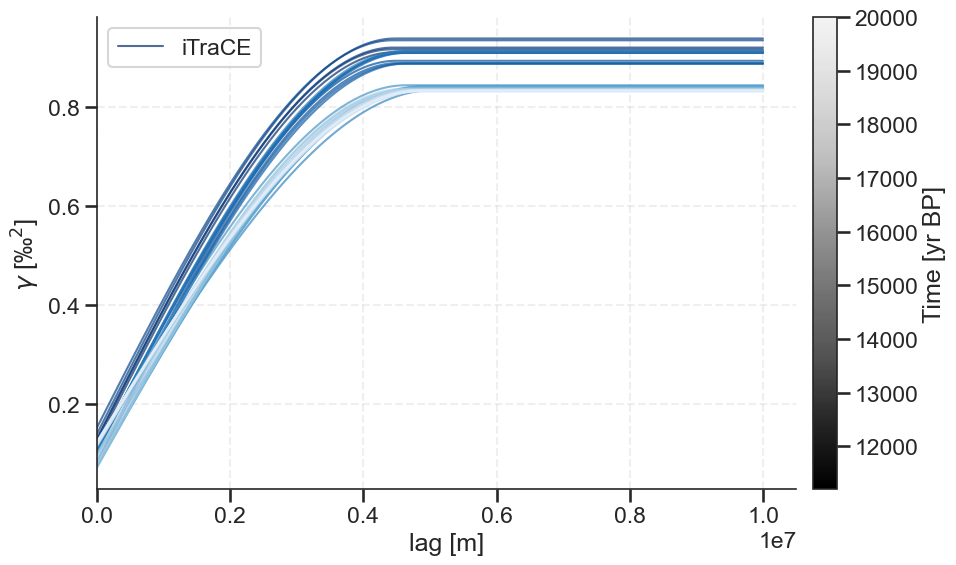

In [37]:
from geostat_isoscapes_tools import variogram_models
import matplotlib.cm as cm
from matplotlib.colors import Normalize, ListedColormap

model = variogram_models.CompositeModel('spherical+nugget')
lags = np.linspace(start=0,stop=1e7,num=200)

fig, ax = plt.subplots(figsize=(10, 6))

# Create normalizer for time values (most recent should be darker)
time_min = min(params_df['time'].min(), params_df['time'].min())
time_max = max(params_df['time'].max(), params_df['time'].max())
norm = Normalize(vmin=time_min, vmax=time_max)

# Create truncated colormaps to avoid white shades (use 0.3 to 1.0 range)
full_cmap_blue = cm.get_cmap('Blues_r')
cmap_blue = ListedColormap(full_cmap_blue(np.linspace(0., 0.9, 256)))

for t,vario_t in params_df.groupby('time'):
    color = cmap_blue(norm(t))
    ax.plot(lags,model.get_model_func()(lags,vario_t['range_spherical'].values[0],vario_t['sill_spherical'].values[0],vario_t['nugget'].values[0]), '-', linewidth=1.5, alpha=0.7, color=color, label='iTraCE' if t==time_min else None)

# for t,vario_t in vario_sisal_df.groupby('time') :
#     color = cmap_orange(norm(t))
#     ax.plot(lags,model.get_model_func()(lags,vario_t['range_spherical'].values[0],vario_t['sill_spherical'].values[0],vario_t['nugget'].values[0]), '-', linewidth=1.5, alpha=0.7, color=color, label='SISAL' if t==time_min else None)

ax.set_xlabel('lag [m]')
ax.set_xlim(0)
ax.set_ylabel(r'$\gamma$ [‰$^2$]')
# ax.set_title('SISAL and iTrace empirical residual variograms over 20-11 ka')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
ax.legend()

full_cmap_grey = cm.get_cmap('Greys_r')
cmap_grey = ListedColormap(full_cmap_grey(np.linspace(0., 0.9, 256)))
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap_grey), ax=ax, pad=0.02)
cbar.set_label('Time [yr BP]')

plt.tight_layout()
plt.show()


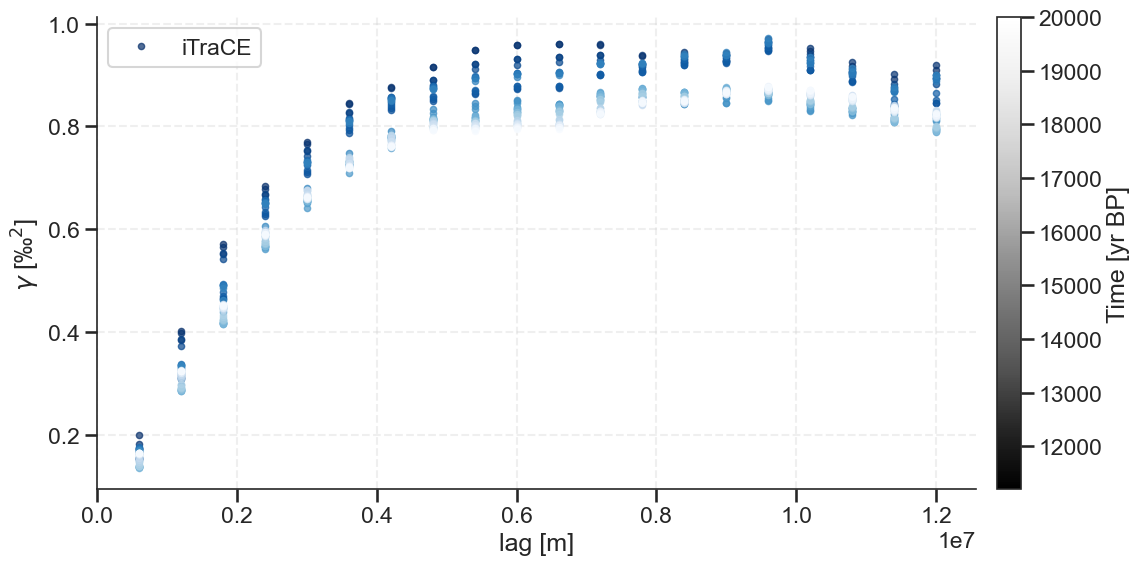

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

time_min, time_max = min(itrace_df.time.unique()), max(itrace_df.time.unique())
norm = Normalize(vmin=time_min, vmax=time_max)
cmap_blue = cm.get_cmap('Blues_r')  # reversed: most recent (lower time) = darker
cmap_orange = cm.get_cmap('Oranges_r')

i=0
for t,df_t in itrace_df.groupby('time') :
    bin_centers = ref_bins - np.r_[ref_bins[0],np.diff(ref_bins)]/2
    color = cmap_blue(norm(t))
    ax.plot(ref_bins, gammas[i], '.', linewidth=1.5, alpha=0.7, color=color, label='iTraCE' if t==time_min else None) #
    i = i+1

ax.set_xlabel('lag [m]')
ax.set_xlim(0)
ax.set_ylabel(r'$\gamma$ [‰$^2$]')
# ax.set_title('SISAL and iTrace empirical residual variograms over 20-11 ka')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
ax.legend()

# Add colorbar showing time progression
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap='Greys_r'), ax=ax, pad=0.02)
cbar.set_label('Time [yr BP]')

plt.tight_layout()
# plt.savefig('../output/essd_figs/fig4_line_shading.png',dpi=300)
plt.show()
